In [29]:
import keras
from IPython.core.pylabtools import figsize
from keras import layers
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import expit

In [30]:
from tensorflow.keras import layers

layers.Conv2D(
    filters=64,          # 1. 특징 맵의 개수 (출력 채널 수)
    kernel_size=(3, 3),  # 2. 필터의 가로·세로 크기
    strides=(1, 1),      # 3. 필터의 이동 보폭 (스트라이드)
    padding='same',      # 4. 패딩 방식 ('same' 또는 'valid')
    activation='relu'    # 5. 활성화 함수
)


<Conv2D name=conv2d_6, built=False>

.

📌 CNN Convolution 레이어 주요 파라미터 정리

① filters (필터 개수)
의미: 이 레이어에서 몇 개의 필터를 사용할지 결정합니다. (출력되는 특징 맵의 개수)

💡 우리가 나눈 이야기: 층이 깊어질수록 더 다양하고 구체적인 단서가 필요하므로 특징 맵이 많아집니다.

Tip: 보통 모델 초반부에는 filters=32, 중반부에는 64, 후반부에는 128처럼 점진적으로 숫자를 키워 설계합니다.

② kernel_size (필터 크기)
의미: 이미지를 훑을 돋보기(필터)의 가로·세로 크기입니다.

💡 팁: 보통 정방형 행렬을 쓰기 때문에 숫자를 하나만 써도 되고(kernel_size=3), 튜플로 명시해도 됩니다((3, 3)). 딥러닝 역사상 가장 효율적이라고 증명된 3 또는 5를 주로 사용합니다.

③ strides (스트라이드)
의미: 필터가 한 번에 몇 칸씩 이동할지 설정하는 보폭입니다.

💡 우리가 나눈 이야기: 기본값은 (1, 1)로 한 칸씩 촘촘하게 이동합니다. 만약 가로·세로 두 칸씩 껑충 뛰면서 특징 맵의 크기를 절반으로 압축하고 싶다면 strides=(2, 2) 혹은 strides=2로 설정하면 됩니다.

④ padding (패딩 옵션)
⚠️ 가장 헷갈리기 쉬운 부분! Keras에서는 복잡한 수식 대신 딱 두 가지 문자열로 선택권을 줍니다.

'valid' (기본값): 패딩을 전혀 하지 않습니다. 테두리에 0을 채우지 않으므로, 합성곱 연산을 거치면 출력되는 특징 맵의 가로·세로 크기가 무조건 줄어듭니다.

'same': 입력 이미지와 똑같은 가로·세로 크기로 출력되도록 컴퓨터가 알아서 자동으로 제로 패딩을 둘러줍니다. (크기 유지가 필요할 때 아주 편리하게 사용됩니다.)

⑤ activation (활성화 함수)
의미: 필터 연산이 끝난 값에 비선형성을 부여하는 함수입니다.

💡 팁: 이미지 처리에서는 특별한 이유가 없다면 무조건 'relu'를 적어준다고 생각하시면 됩니다. (음수 값은 0으로 날리고, 양수 값은 그대로 통과시켜 학습을 원활하게 돕습니다.)

In [31]:
x = np.random.normal(size=(10, 28, 28 ,1))

In [32]:
conv1 = layers.Conv2D(filters=10, kernel_size=(3, 3))

In [33]:
conv_out = conv1(x)

In [34]:
print(conv_out.shape)

(10, 26, 26, 10)


In [35]:
conv2 = layers.Conv2D(filters=10, kernel_size=(3,3), strides=(2,2))

In [36]:
print(conv2(x).shape)

(10, 13, 13, 10)


In [37]:
conv3 = layers.Conv2D(filters=10, kernel_size=(3, 3), strides=(2,2), padding='same')

In [38]:
print(conv3(x).shape)

(10, 14, 14, 10)


In [39]:
conv4 = layers.Conv2D(filters=10, kernel_size=(3,3), padding='same')

In [40]:
print(conv4(x).shape)

(10, 28, 28, 10)


In [41]:
pool1 = layers.AveragePooling2D(pool_size=2)

In [42]:
pool2 = layers.AveragePooling2D(pool_size=3)

In [43]:
print(pool1(x).shape)

(10, 14, 14, 1)


In [44]:
print(pool2(x).shape)

(10, 9, 9, 1)


In [45]:
dense1 = layers.Dense(3)

In [46]:
x2 = np.array([[5, 7]])

In [47]:
print(dense1(x2).shape)

(1, 3)


In [48]:
print(dense1.get_weights())

[array([[-0.83760667,  0.31038737, -0.15163529],
       [ 0.51711345, -0.7284519 ,  0.07842517]], dtype=float32), array([0., 0., 0.], dtype=float32)]


In [49]:
dense1.set_weights([
    np.array([[1, 2, 3], [4, 5, 6]]),
    np.array([0, 0, 0])
])

In [50]:
print(dense1(x2))

tf.Tensor([[33. 45. 57.]], shape=(1, 3), dtype=float32)


In [51]:
weight = dense1.get_weights()[0]

In [52]:
print(np.dot(x2, weight))

[[33. 45. 57.]]


In [53]:
x = np.arange(-10, 10, 0.2)

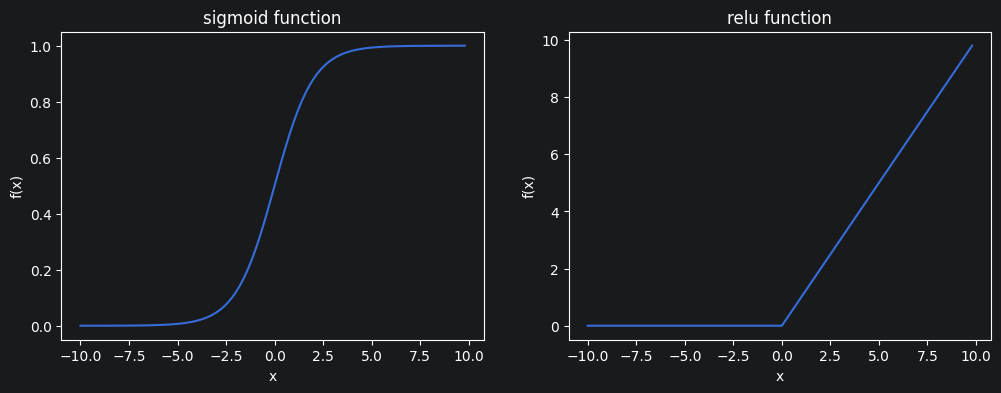

In [54]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].plot(x, expit(x))
axs[0].set_title('sigmoid function')
axs[0].set_xlabel('x')
axs[0].set_ylabel('f(x)')
axs[1].plot(x, x.clip(0))
axs[1].set_title('relu function')
axs[1].set_xlabel('x')
axs[1].set_ylabel('f(x)')
plt.show()

In [55]:
lenet5 = keras.Sequential()
lenet5.add(layers.Input(shape=(28, 28, 1)))
lenet5.add(layers.Conv2D(filters=6, kernel_size=5, activation='sigmoid', padding='same'))
